# 07 — C-MAPSS Remaining Useful Life (RUL) Regression

Activates the second dataset acquired back in Phase 0 but not yet modeled. Different task
entirely from the CWRU fault-classification work: given a multivariate sensor time series
for a turbofan engine, predict how many operating cycles remain before failure.

Follows the field's standard protocol for this exact benchmark (FD001 subset) so results are
methodologically comparable to published work:
- **RUL capping**: training labels are capped at 125 cycles (`src/data/cmapss.py`) - RUL is only
  learnable close to failure, a linear target from cycle 1 is unlearnable noise.
- **Sliding-window sequences**: 30-cycle windows of sensor readings predict the RUL at the
  window's last cycle.
- **Unit-level train/val split**: matches [docs/datasets.md](../docs/datasets.md)'s split
  strategy - no cycle from a validation unit's trajectory leaks into training.
- **Standard test protocol**: the dataset's own test trajectories are pre-truncated; one
  prediction per unit from its last window, scored against `RUL_FD001.txt`'s true (uncapped)
  values using RMSE and the PHM08/C-MAPSS asymmetric scoring function
  (`src/models/rul_metrics.py`) - the field's standard metric, penalizing late (overestimated
  RUL) predictions more heavily than early ones.

Two models, mirroring the classical-vs-deep-learning comparison from Phases 1-2: a Gradient
Boosting regressor on window-summary statistics, and an LSTM directly over the raw sequences.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.cmapss import (
    add_capped_rul,
    build_test_sequences,
    build_train_sequences,
    load_subset,
    select_informative_columns,
)
from src.data.cmapss_torch import RulSequenceDataset, compute_sequence_train_stats
from src.models.lstm_rul import LstmRul, predict as lstm_predict, train_lstm
from src.models.rul_baseline import summarize_windows, train_gbr
from src.models.rul_metrics import nasa_score, rmse

CMAPSS_DIR = Path.cwd().parent / "data" / "raw" / "cmapss"
WINDOW_SIZE = 30
torch.manual_seed(42)
np.random.seed(42)


## Load FD001, cap RUL, select informative sensors

In [2]:
train_df, test_df, test_true_rul = load_subset(CMAPSS_DIR, subset="FD001")
train_df = add_capped_rul(train_df, cap=125)

feature_cols = select_informative_columns(train_df)
print(f"{len(feature_cols)} informative columns (of {21 + 3} raw sensor/setting columns):")
print(feature_cols)


17 informative columns (of 24 raw sensor/setting columns):
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'op_setting_1', 'op_setting_2']


## Unit-level train/val split (no unit's cycles span both sides)

In [3]:
rng = np.random.default_rng(42)
unit_ids = train_df["unit_id"].unique()
rng.shuffle(unit_ids)
n_val_units = int(0.15 * len(unit_ids))
val_units = set(unit_ids[:n_val_units])
train_units = set(unit_ids[n_val_units:])

train_split_df = train_df[train_df["unit_id"].isin(train_units)]
val_split_df = train_df[train_df["unit_id"].isin(val_units)]
print(f"train units: {len(train_units)} | val units: {len(val_units)}")

train_seq, train_y, _ = build_train_sequences(train_split_df, feature_cols, window_size=WINDOW_SIZE)
val_seq, val_y, _ = build_train_sequences(val_split_df, feature_cols, window_size=WINDOW_SIZE)
test_seq, test_unit_ids = build_test_sequences(test_df, feature_cols, window_size=WINDOW_SIZE)
print(f"train windows: {train_seq.shape} | val windows: {val_seq.shape} | test windows: {test_seq.shape}")


train units: 85 | val units: 15


train windows: (15332, 30, 17) | val windows: (2399, 30, 17) | test windows: (100, 30, 17)


## Model 1: Gradient Boosting on window-summary features

Classical baseline - each window collapsed to per-sensor mean/std/last-value (`summarize_windows`).


In [4]:
X_train_flat = summarize_windows(train_seq)
X_test_flat = summarize_windows(test_seq)

gbr = train_gbr(X_train_flat, train_y)
gbr_test_pred = gbr.predict(X_test_flat)

gbr_rmse = rmse(test_true_rul, gbr_test_pred)
gbr_score = nasa_score(test_true_rul, gbr_test_pred)
print(f"Gradient Boosting - test RMSE: {gbr_rmse:.2f} cycles | NASA score: {gbr_score:.1f}")


Gradient Boosting - test RMSE: 17.04 cycles | NASA score: 582.8


## Model 2: LSTM over the raw sequences

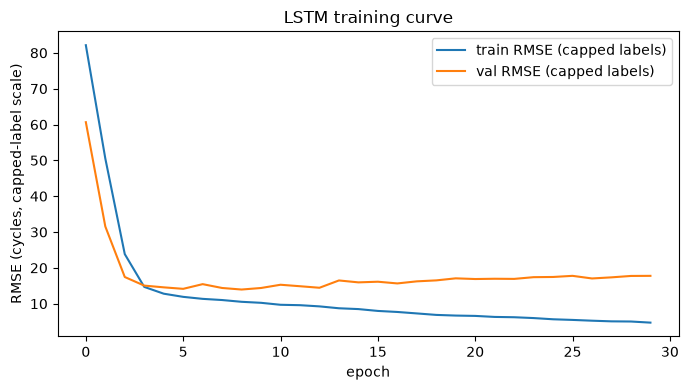

In [5]:
train_mean, train_std = compute_sequence_train_stats(train_seq)

train_loader = DataLoader(RulSequenceDataset(train_seq, train_y, train_mean, train_std), batch_size=128, shuffle=True)
val_loader = DataLoader(RulSequenceDataset(val_seq, val_y, train_mean, train_std), batch_size=128)
# test targets aren't used for training/monitoring, only for final scoring - dummy zeros here
test_loader = DataLoader(
    RulSequenceDataset(test_seq, np.zeros(len(test_seq)), train_mean, train_std), batch_size=128
)

lstm_model = LstmRul(n_features=len(feature_cols), hidden_size=64, num_layers=2, dropout=0.2)
history = train_lstm(lstm_model, train_loader, val_loader, epochs=30, lr=1e-3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([h["epoch"] for h in history], [h["train_rmse"] for h in history], label="train RMSE (capped labels)")
ax.plot([h["epoch"] for h in history], [h["val_rmse"] for h in history], label="val RMSE (capped labels)")
ax.set_xlabel("epoch")
ax.set_ylabel("RMSE (cycles, capped-label scale)")
ax.set_title("LSTM training curve")
ax.legend()
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "cmapss_lstm_training_curve.png", dpi=150)
plt.show()


In [6]:
lstm_test_pred, _ = lstm_predict(lstm_model, test_loader)

lstm_rmse = rmse(test_true_rul, lstm_test_pred)
lstm_score = nasa_score(test_true_rul, lstm_test_pred)
print(f"LSTM - test RMSE: {lstm_rmse:.2f} cycles | NASA score: {lstm_score:.1f}")


LSTM - test RMSE: 18.89 cycles | NASA score: 991.4


## Comparison

In [7]:
summary = pd.DataFrame([
    {"model": "Gradient Boosting (classical)", "rmse_cycles": gbr_rmse, "nasa_score": gbr_score},
    {"model": "LSTM (deep learning)", "rmse_cycles": lstm_rmse, "nasa_score": lstm_score},
])
summary


,model,rmse_cycles,nasa_score
0,Gradient Boosting (classical),17.042616,582.832280
1,LSTM (deep learning),18.893486,991.382684


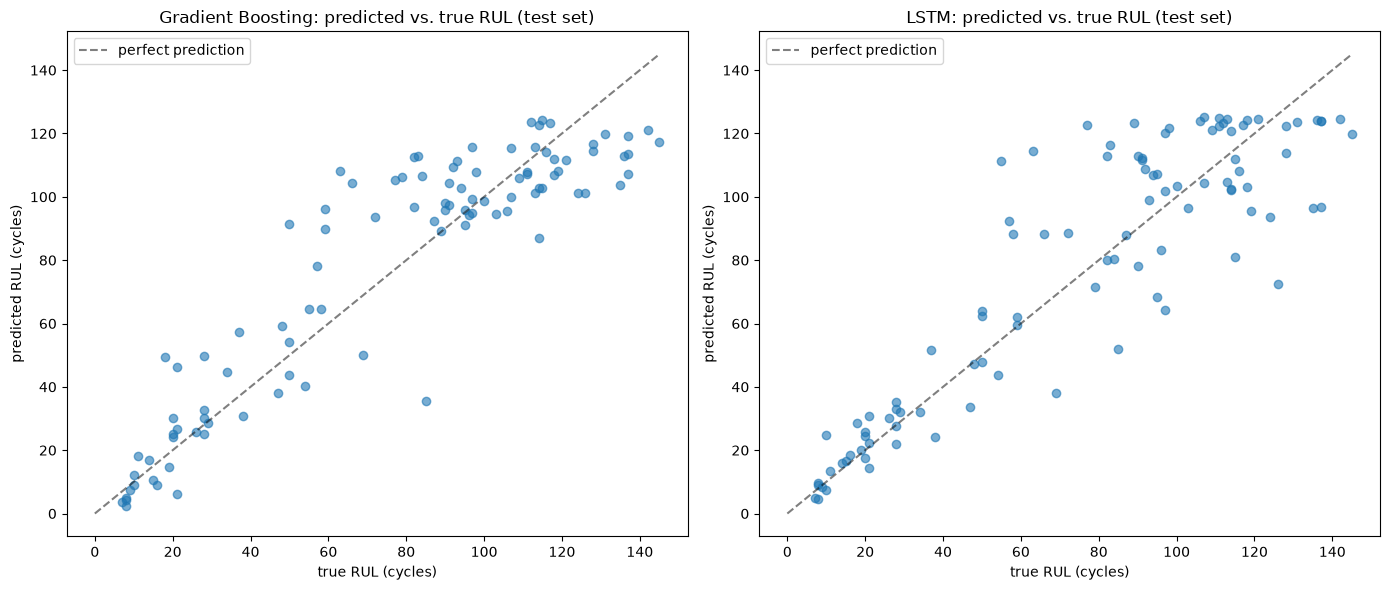

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pred, title in [(axes[0], gbr_test_pred, "Gradient Boosting"), (axes[1], lstm_test_pred, "LSTM")]:
    ax.scatter(test_true_rul, pred, alpha=0.6)
    lims = [0, max(test_true_rul.max(), pred.max())]
    ax.plot(lims, lims, "k--", alpha=0.5, label="perfect prediction")
    ax.set_xlabel("true RUL (cycles)")
    ax.set_ylabel("predicted RUL (cycles)")
    ax.set_title(f"{title}: predicted vs. true RUL (test set)")
    ax.legend()
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "cmapss_predicted_vs_true_rul.png", dpi=150)
plt.show()
